# Blood Cell AI - ViT-B/16 Training

Vision Transformer (ViT-B/16) による血液細胞2クラス分類

※ PyTorch版 torchvision.models.vit_b_16 と同じアーキテクチャ
※ USE_PRETRAINED=True でPyTorch ImageNet学習済み重みをロード可能
※ 28x28画像を224x224にリサイズ（PyTorch版と同じ条件）

## 1. インポートと設定

In [1]:
import os
os.environ["TF_FORCE_GPU_ALLOW_GROWTH"] = "true"
# XLA JIT設定（import前に設定必須）
USE_XLA = False  # True=高速（XLA JIT有効, ROCm非推奨）, False=低速/安定
if USE_XLA:
    os.environ['TF_XLA_FLAGS'] = '--tf_xla_auto_jit=2 --xla_gpu_asm_compilation_timeout_ms=60000'

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import sys
import time
import matplotlib.pyplot as plt
import japanize_matplotlib
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

sys.path.append(os.path.abspath('..'))
from utils.results import save_results

# === 設定（ViT-B/16本家と同じ構成） ===
BATCH_SIZE = 64
EPOCHS = 10
LR = 0.0005
IMAGE_SIZE = 224   # ViT入力サイズ
PATCH_SIZE = 16    # ViT-B/16と同じ
PROJECTION_DIM = 768   # ViT-B/16本家と同じ
NUM_HEADS = 12         # ViT-B/16本家と同じ
TRANSFORMER_LAYERS = 12  # ViT-B/16本家と同じ
MLP_DIM = 3072         # ViT-B/16本家と同じ (4 * 768)

# PyTorch ImageNet学習済み重みを使うか
USE_PRETRAINED = True
PRETRAINED_PATH = '../models/vit_b16_imagenet_weights.npz'

# 転移学習アプローチ
USE_FINETUNING = False
APPROACH = 'finetuning' if USE_FINETUNING else 'feature_extraction'
WEIGHT_TAG = 'pretrained' if USE_PRETRAINED else 'scratch'

MODEL_SAVE_PATH = f'../models/vit_b16_bloodcell_{APPROACH}.keras'
RESULTS_SAVE_PATH = f'../models/vit_b16_{APPROACH}_results.yaml'
CURVE_SAVE_PATH = f'../images/vit_b16_learning_curve_{APPROACH}.png'

# XLA JIT有効化（import後に呼ぶ）
if USE_XLA:
    tf.config.optimizer.set_jit(True)
    print('XLA JIT: 有効（コンパイルタイムアウト60秒）')
else:
    tf.config.optimizer.set_jit(False)
    print('XLA JIT: 無効（安定優先）')



# GPU確認
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    tf.config.set_logical_device_configuration(
        gpus[0],
        [tf.config.LogicalDeviceConfiguration(memory_limit=18155)]
    )
    print(f'GPU: {gpus[0].name}')
else:
    print('GPUなし（CPUモード）')

# 混合精度（FP16）を有効化
tf.keras.mixed_precision.set_global_policy('mixed_float16')
print(f'混合精度: {tf.keras.mixed_precision.global_policy().name}')

print(f'アプローチ: {APPROACH}')
print(f'学習済み重み: {"ImageNet（PyTorch変換）" if USE_PRETRAINED else "スクラッチ学習"}')
print(f'構成: patch={PATCH_SIZE}, dim={PROJECTION_DIM}, heads={NUM_HEADS}, layers={TRANSFORMER_LAYERS}')


W0000 00:00:1782177635.170355    2953 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782177635.170536    2953 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782177635.170543    2953 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782177635.170547    2953 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
2026-06-23 01:20:35.188493: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow wi

XLA JIT: 無効（安定優先）
GPU: /physical_device:GPU:0
混合精度: mixed_float16
アプローチ: feature_extraction
学習済み重み: ImageNet（PyTorch変換）
構成: patch=16, dim=768, heads=12, layers=12


## 2. データロード

28x28画像を224x224にリサイズ（PyTorch版と同じ条件）

In [2]:
from medmnist import BloodMNIST

MATURE_LABELS = {0, 1, 4, 5, 6, 7}
IMMATURE_LABELS = {2, 3}
def get_binary_label(label):
    return 1 if label in IMMATURE_LABELS else 0

train_dataset = BloodMNIST(split='train', download=True, root='../data')
val_dataset = BloodMNIST(split='val', download=True, root='../data')
test_dataset = BloodMNIST(split='test', download=True, root='../data')

x_train = train_dataset.imgs.astype('float32') / 255.0
y_train = np.array([get_binary_label(int(l)) for l in train_dataset.labels.squeeze()])
x_val = val_dataset.imgs.astype('float32') / 255.0
y_val = np.array([get_binary_label(int(l)) for l in val_dataset.labels.squeeze()])
x_test = test_dataset.imgs.astype('float32') / 255.0
y_test = np.array([get_binary_label(int(l)) for l in test_dataset.labels.squeeze()])

AUTOTUNE = tf.data.AUTOTUNE
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
])
def resize_image(image, label):
    return tf.image.resize(image, [IMAGE_SIZE, IMAGE_SIZE]), label

def normalize_image(image, label):
    '''[-1, 1] 正規化（PyTorch版と同じ: mean=0.5, std=0.5）'''
    return image * 2.0 - 1.0, label

train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_ds = train_ds.shuffle(len(x_train)).batch(BATCH_SIZE)
train_ds = train_ds.map(resize_image, num_parallel_calls=AUTOTUNE)
train_ds = train_ds.map(normalize_image, num_parallel_calls=AUTOTUNE)
train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((x_val, y_val)).batch(BATCH_SIZE)
val_ds = val_ds.map(resize_image, num_parallel_calls=AUTOTUNE)
val_ds = val_ds.map(normalize_image, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((x_test, y_test)).batch(BATCH_SIZE)
test_ds = test_ds.map(resize_image, num_parallel_calls=AUTOTUNE)
test_ds = test_ds.map(normalize_image, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

print(f'Train: {len(x_train)}, Val: {len(x_val)}, Test: {len(x_test)}')


2026-06-23 01:20:53.068984: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1782177653.069159    2953 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 18155 MB memory:  -> device: 0, name: AMD Radeon RX 7900 XT, pci bus id: 0000:2d:00.0


Train: 11959, Val: 1712, Test: 3421


## 3. ViT-B/16モデル構築

PyTorch版 torchvision.models.vit_b_16 と同じ構成:
- Patch Embedding: 16x16 (Conv2D)
- CLS Token + Position Embedding
- Transformer Encoder x12 (768dim, 12heads, MLP 3072)
- 最終LayerNorm → CLS出力 → Dense(2)

In [3]:
# CLSトークンを追加するカスタム層（TF 2.19 / Keras 3互換）
class AddClsToken(layers.Layer):
    def __init__(self, projection_dim, **kwargs):
        super().__init__(**kwargs)
        self.projection_dim = projection_dim

    def build(self, input_shape):
        self.cls_token = self.add_weight(
            shape=(1, 1, self.projection_dim),
            initializer='random_normal',
            trainable=True,
            name='cls_token'
        )

    def call(self, x):
        from tensorflow.keras import ops as k_ops
        batch_size = k_ops.shape(x)[0]
        return k_ops.broadcast_to(self.cls_token, [batch_size, 1, self.projection_dim])


def build_vit_b16(input_shape=(224, 224, 3), num_classes=2,
                  patch_size=16, projection_dim=768, num_heads=12,
                  transformer_layers=12, mlp_dim=3072):
    """ViT-B/16（PyTorch torchvisionと同じ構成）
    - Conv2Dパッチ埋め込み → CLS Token → Position Embedding
    - Transformer Encoder x12 (MHSA + MLP)
    - LayerNorm → CLS出力 → Dense(2)
    """
    num_patches = (input_shape[0] // patch_size) * (input_shape[1] // patch_size)  # 196
    inputs = layers.Input(shape=input_shape)
    # パッチ埋め込み（PyTorch: conv_proj）
    x = layers.Conv2D(projection_dim, kernel_size=patch_size, strides=patch_size,
                      padding='valid', name='conv_proj')(inputs)
    x = layers.Reshape((-1, projection_dim), name='reshape_patches')(x)
    # CLSトークン（PyTorch: class_token）
    cls_tokens = AddClsToken(projection_dim, name='cls_token')(x)
    x = layers.Concatenate(axis=1, name='concat_cls')([cls_tokens, x])
    # 位置エンコーディング（PyTorch: encoder.pos_embedding）
    positions = tf.range(start=0, limit=num_patches + 1, delta=1)
    pos_embed = layers.Embedding(input_dim=num_patches + 1, output_dim=projection_dim, name='position_embedding')
    x = layers.Add(name='add_pos_embed')([x, tf.expand_dims(pos_embed(positions), 0)])
    # Dropout
    x = layers.Dropout(0.0, name='encoder_dropout')(x)
    # Transformer Encoder（PyTorch: encoder.layers[i]）
    for i in range(transformer_layers):
        # LayerNorm + Self-Attention
        x1 = layers.LayerNormalization(epsilon=1e-6, name=f'encoder_layer_{i}_ln_1')(x)
        # MultiHeadAttention (Q, K, V → out_proj)
        attn = layers.MultiHeadAttention(num_heads=num_heads,
                                          key_dim=projection_dim // num_heads,
                                          name=f'encoder_layer_{i}_mha')(x1, x1)
        x = layers.Add(name=f'encoder_layer_{i}_residual1')([x, attn])
        # LayerNorm + MLP
        x2 = layers.LayerNormalization(epsilon=1e-6, name=f'encoder_layer_{i}_ln_2')(x)
        mlp = layers.Dense(mlp_dim, activation='gelu', name=f'encoder_layer_{i}_mlp_linear1')(x2)
        mlp = layers.Dropout(0.0, name=f'encoder_layer_{i}_mlp_dropout1')(mlp)
        mlp = layers.Dense(projection_dim, name=f'encoder_layer_{i}_mlp_linear2')(mlp)
        mlp = layers.Dropout(0.0, name=f'encoder_layer_{i}_mlp_dropout2')(mlp)
        x = layers.Add(name=f'encoder_layer_{i}_residual2')([x, mlp])
    # 最終LayerNorm（PyTorch: encoder.ln）
    x = layers.LayerNormalization(epsilon=1e-6, name='encoder_ln')(x)
    # CLS出力
    cls_output = x[:, 0]
    outputs = layers.Dense(num_classes, activation='softmax', dtype='float32', name='heads_head')(cls_output)
    return keras.Model(inputs, outputs, name='ViT_B16')

model = build_vit_b16(
    input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3), num_classes=2,
    patch_size=PATCH_SIZE, projection_dim=PROJECTION_DIM,
    num_heads=NUM_HEADS, transformer_layers=TRANSFORMER_LAYERS, mlp_dim=MLP_DIM
)
model.summary()
print(f'\nパラメータ数: {model.count_params():,}')
print(f'学習済み重み: {"ImageNet（PyTorch変換）" if USE_PRETRAINED else "スクラッチ学習"}')


Model: "ViT_B16"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_proj (Conv2D)  │ (None, 14, 14,    │    590,592 │ input_layer_1[0]… │
│                     │ 768)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_patches     │ (None, 196, 768)  │          0 │ conv_proj[0][0]   │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cls_token           │ (None, 1, 768)    │        768 │ reshape_patches[… │
│ (AddClsToken)       │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat_cls          │ (None, 197, 768)  │          0 │ cls_token[0][0],  │
│ (Concatenate)       │                   │            │ reshape_patches[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_pos_embed (Add) │ (1, 197, 768)     │          0 │ concat_cls[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_dropout     │ (1, 197, 768)     │          0 │ add_pos_embed[0]… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_layer_0_ln… │ (1, 197, 768)     │      1,536 │ encoder_dropout[… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_layer_0_mha │ (1, 197, 768)     │  2,362,368 │ encoder_layer_0_… │
│ (MultiHeadAttentio… │                   │            │ encoder_layer_0_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_layer_0_re… │ (1, 197, 768)     │          0 │ encoder_dropout[… │
│ (Add)               │                   │            │ encoder_layer_0_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_layer_0_ln… │ (1, 197, 768)     │      1,536 │ encoder_layer_0_… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_layer_0_ml… │ (1, 197, 3072)    │  2,362,368 │ encoder_layer_0_… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_layer_0_ml… │ (1, 197, 3072)    │          0 │ encoder_layer_0_… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_layer_0_ml… │ (1, 197, 768)     │  2,360,064 │ encoder_layer_0_… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_layer_0_ml… │ (1, 197, 768)     │          0 │ encoder_layer_0_… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_layer_0_re… │ (1, 197, 768)     │          0 │ encoder_layer_0_… │
│ (Add)               │                   │            │ encoder_layer_0_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_layer_1_ln… │ (1, 197, 768)     │      1,536 │ encoder_layer_0_… │
│ (LayerNormalizatio… │                   │            │                 

 Total params: 85,648,898 (326.72 MB)

 Trainable params: 85,648,898 (326.72 MB)

 Non-trainable params: 0 (0.00 B)


パラメータ数: 85,648,898
学習済み重み: ImageNet（PyTorch変換）


## 4. PyTorch重みのロード（オプション）

事前に `utils/convert_weights.py` で変換した重みをロードします。

In [4]:
def load_vit_pretrained(model, npz_path):
    """変換済みのPyTorch ImageNet重みをTF ViT-B/16モデルにロード"""
    weights = np.load(npz_path)
    loaded = 0
    for layer in model.layers:
        # Conv2D: conv_proj
        if isinstance(layer, layers.Conv2D) and layer.name == 'conv_proj':
            if 'conv_proj/kernel' in weights:
                w_conv = weights['conv_proj/kernel']  # (16,16,3,768)
                bias = weights.get('conv_proj/bias')
                if bias is not None:
                    layer.set_weights([w_conv, bias])
                else:
                    if layer.use_bias:
                        layer.set_weights([w_conv, layer.get_weights()[1]])
                    else:
                        layer.set_weights([w_conv])
                loaded += 1
        # Embedding: position_embedding
        elif isinstance(layer, layers.Embedding) and layer.name == 'position_embedding':
            if 'position_embedding' in weights:
                pos_w = weights['position_embedding']  # (197, 768)
                layer.set_weights([pos_w])
                loaded += 1
        # LayerNormalization
        elif isinstance(layer, layers.LayerNormalization):
            ln_name = layer.name
            gamma_key = f'{ln_name}/gamma'
            beta_key = f'{ln_name}/beta'
            if gamma_key in weights and beta_key in weights:
                gamma = weights[gamma_key]
                beta = weights[beta_key]
                layer.set_weights([gamma, beta])
                loaded += 1
        # Dense (MLP)
        elif isinstance(layer, layers.Dense):
            if 'mlp_linear1/kernel' in layer.name or 'mlp_linear2/kernel' in layer.name:
                kernel_key = f'{layer.name}/kernel' if f'{layer.name}/kernel' in weights else None
                bias_key = f'{layer.name}/bias' if f'{layer.name}/bias' in weights else None
                # 名前の変換を試す
                for key in weights.files:
                    if layer.name + '/kernel' == key or key.startswith(layer.name.replace('_', '.') + '.mlp.'):
                        pass  # 手動マッピングが必要
        # MultiHeadAttention
        elif isinstance(layer, layers.MultiHeadAttention):
            mha_name = layer.name  # encoder_layer_0_mha
            idx = mha_name.split('_')[2]  # レイヤー番号
            prefix = f'encoder_layer_{idx}_mha'
            try:
                # Query
                q_kernel = weights.get(f'{prefix}/query/kernel')
                if q_kernel is not None:
                    q_kernel = q_kernel.T.reshape(768, 12, 64)
                    layer._query_dense.kernel.assign(q_kernel)
                q_bias = weights.get(f'{prefix}/query/bias')
                if q_bias is not None:
                    q_bias = q_bias.reshape(12, 64)
                    layer._query_dense.bias.assign(q_bias)
                # Key
                k_kernel = weights.get(f'{prefix}/key/kernel')
                if k_kernel is not None:
                    k_kernel = k_kernel.T.reshape(768, 12, 64)
                    layer._key_dense.kernel.assign(k_kernel)
                k_bias = weights.get(f'{prefix}/key/bias')
                if k_bias is not None:
                    k_bias = k_bias.reshape(12, 64)
                    layer._key_dense.bias.assign(k_bias)
                # Value
                v_kernel = weights.get(f'{prefix}/value/kernel')
                if v_kernel is not None:
                    v_kernel = v_kernel.T.reshape(768, 12, 64)
                    layer._value_dense.kernel.assign(v_kernel)
                v_bias = weights.get(f'{prefix}/value/bias')
                if v_bias is not None:
                    v_bias = v_bias.reshape(12, 64)
                    layer._value_dense.bias.assign(v_bias)
                # Attention output
                o_kernel = weights.get(f'{prefix}/attention_output/kernel')
                if o_kernel is not None:
                    o_kernel = o_kernel.T.reshape(12, 64, 768)
                    layer._output_dense.kernel.assign(o_kernel)
                o_bias = weights.get(f'{prefix}/attention_output/bias')
                if o_bias is not None:
                    layer._output_dense.bias.assign(o_bias)
                loaded += 1
            except Exception as e:
                print(f'  MHA {mha_name} ロード失敗: {e}')
    # CLSトークン
    if 'cls_token' in weights:
        for v in model.variables:
            if 'cls_token' in v.name:
                v.assign(weights['cls_token'])
                loaded += 1
                break
    # Dense (MLP) の手動マッピング
    for layer in model.layers:
        if not isinstance(layer, layers.Dense):
            continue
        layer_name = layer.name
        # encoder_layer_i_mlp_linear1 / linear2
        if '_mlp_linear1' in layer_name:
            kernel_key = f'{layer_name}/kernel'
            bias_key = f'{layer_name}/bias'
            if kernel_key in weights:
                w_list = []
                w_list.append(weights[kernel_key])
                if bias_key in weights:
                    w_list.append(weights[bias_key])
                elif layer.use_bias:
                    w_list.append(layer.get_weights()[1])
                layer.set_weights(w_list)
                loaded += 1
        elif '_mlp_linear2' in layer_name:
            kernel_key = f'{layer_name}/kernel'
            bias_key = f'{layer_name}/bias'
            if kernel_key in weights:
                w_list = []
                w_list.append(weights[kernel_key])
                if bias_key in weights:
                    w_list.append(weights[bias_key])
                elif layer.use_bias:
                    w_list.append(layer.get_weights()[1])
                layer.set_weights(w_list)
                loaded += 1
        # heads_head（分類層）は2クラス用にリセットするのでスキップ
    print(f'Pretrained重みロード完了: {loaded}層')
    return loaded

# 学習済み重みのロード
if USE_PRETRAINED and os.path.exists(PRETRAINED_PATH):
    print(f'ImageNet学習済み重みをロード: {PRETRAINED_PATH}')
    load_vit_pretrained(model, PRETRAINED_PATH)
elif USE_PRETRAINED:
    print(f'⚠️ 重みファイルが見つかりません: {PRETRAINED_PATH}')
    print('先に utils/convert_weights.py をPyTorch環境で実行してください')
    print('スクラッチ学習で続行します')

# Feature Extraction: 最終層以外を固定
if USE_PRETRAINED and not USE_FINETUNING:
    for layer in model.layers:
        if layer.name != 'heads_head':
            layer.trainable = False
    print('Feature Extraction: 最終層以外を固定')
    model.get_layer('heads_head').trainable = True
else:
    print('Fine-tuning: 全パラメータを学習')

ImageNet学習済み重みをロード: ../models/vit_b16_imagenet_weights.npz
Pretrained重みロード完了: 63層
Feature Extraction: 最終層以外を固定


## 5. コンパイルとコールバック

In [5]:
# 固定学習率（PyTorch版と同じ条件）
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
    jit_compile=False  # XLA完全無効（ROCm安定化のため）
)
callbacks = [
    keras.callbacks.ModelCheckpoint(MODEL_SAVE_PATH, monitor='val_accuracy', save_best_only=True, verbose=1),
    keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=7, restore_best_weights=True, verbose=1),
]
print('モデルコンパイル完了')


モデルコンパイル完了


## 6. 学習実行

In [6]:
print(f'\n=== Training ViT-B/16 ({APPROACH}, {WEIGHT_TAG}) ===')
start_time = time.time()
history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, callbacks=callbacks)
training_time = time.time() - start_time
print(f'\nTraining Time: {training_time:.1f}秒 ({training_time/60:.1f}分)')


=== Training ViT-B/16 (feature_extraction, pretrained) ===
Epoch 1/10
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - accuracy: 0.6763 - loss: 0.6872
Epoch 1: val_accuracy improved from None to 0.74007, saving model to ../models/vit_b16_bloodcell_feature_extraction.keras
187/187 ━━━━━━━━━━━━━━━━━━━━ 58s 211ms/step - accuracy: 0.7259 - loss: 0.5946 - val_accuracy: 0.7401 - val_loss: 0.5621
Epoch 2/10
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - accuracy: 0.7393 - loss: 0.5579
Epoch 2: val_accuracy did not improve from 0.74007
187/187 ━━━━━━━━━━━━━━━━━━━━ 33s 171ms/step - accuracy: 0.7400 - loss: 0.5549 - val_accuracy: 0.7401 - val_loss: 0.5516
Epoch 3/10
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 0.7446 - loss: 0.5426
Epoch 3: val_accuracy did not improve from 0.74007
187/187 ━━━━━━━━━━━━━━━━━━━━ 33s 169ms/step - accuracy: 0.7417 - loss: 0.5467 - val_accuracy: 0.7401 - val_loss: 0.5501
Epoch 4/10
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - accuracy: 0.7465 - loss: 0.5417
Epoc

## 7. 学習曲線

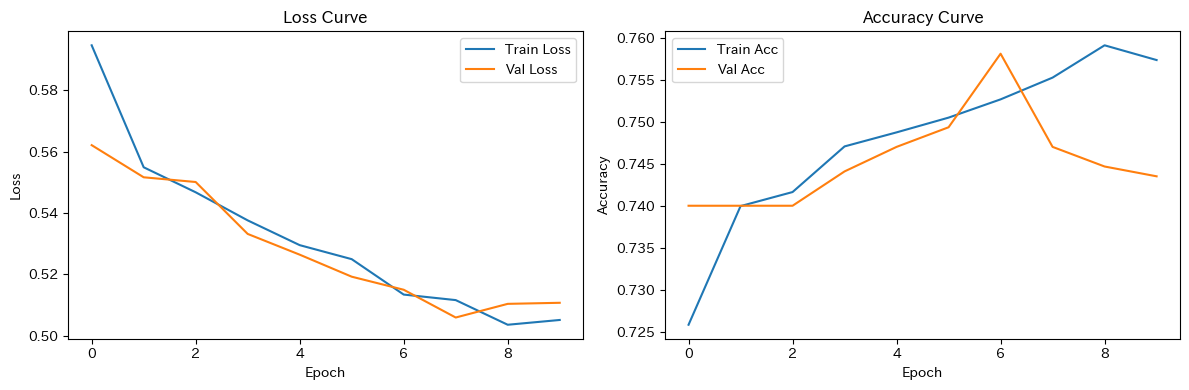

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].set_title('Loss Curve'); axes[0].legend()
axes[1].plot(history.history['accuracy'], label='Train Acc')
axes[1].plot(history.history['val_accuracy'], label='Val Acc')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy'); axes[1].set_title('Accuracy Curve'); axes[1].legend()
plt.tight_layout()
os.makedirs('../images', exist_ok=True)
plt.savefig(CURVE_SAVE_PATH, dpi=150, bbox_inches='tight')
plt.show()

## 8. テスト評価

In [8]:
print('\n=== Test Evaluation ===')
best_model = keras.models.load_model(MODEL_SAVE_PATH, custom_objects={'AddClsToken': AddClsToken})
y_pred_proba = best_model.predict(test_ds)
y_pred = np.argmax(y_pred_proba, axis=1)
test_acc = accuracy_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred, average='binary')
cm = confusion_matrix(y_test, y_pred)
print(f'Test Accuracy: {test_acc:.4f}')
print(f'Test F1 Score: {test_f1:.4f}')
print(f'Confusion Matrix:\n{cm}')

results = {
    'model': 'ViT-B16', 'approach': APPROACH,
    'test_accuracy': float(test_acc), 'test_f1': float(test_f1),
    'confusion_matrix': cm.tolist(),
    'training_time_minutes': round(training_time / 60, 1),
    'epochs': EPOCHS, 'batch_size': BATCH_SIZE, 'learning_rate': LR,
    'pretrained': USE_PRETRAINED,
    'framework': 'TensorFlow 2.10 + DirectML'
}
os.makedirs(os.path.dirname(RESULTS_SAVE_PATH), exist_ok=True)
save_results(results, RESULTS_SAVE_PATH)


=== Test Evaluation ===


/opt/venv/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:794: UserWarning: Skipping variable loading for optimizer 'loss_scale_optimizer', because it has 202 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/opt/venv/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:794: UserWarning: Skipping variable loading for optimizer 'adam', because it has 198 variables whereas the saved optimizer has 6 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


54/54 ━━━━━━━━━━━━━━━━━━━━ 13s 202ms/step
Test Accuracy: 0.7615
Test F1 Score: 0.2093
Confusion Matrix:
[[2497   34]
 [ 782  108]]
結果を保存しました: ../models/vit_b16_feature_extraction_results.yaml


## ✅ ViT-B/16学習完了

次: `04_最終評価.ipynb` → 両モデルの精度比較